# 🔷 Shape Matching using Hu Moments
**Recognition Tasks | Classical Computer Vision**

---

## 💡 Real-World Use Case

A food factory sorting snacks by shape on a conveyor belt:
- 🔺 **Bingo chips** → triangle
- ⭕ **Ring snacks** → circle
- ⬜ **Wafer biscuits** → square

Pipeline: photo → extract shape outline → compute Hu Moments fingerprint → compare → classify ✅

---

## 🧮 Hu Moments — The Shape Fingerprint

7 numbers computed from a shape's contour that stay **identical** even if the shape is:
- 📐 Rotated — same value
- 🔍 Scaled bigger/smaller — same value
- ↔️ Moved to a different position — same value

`cv2.matchShapes()` compares two shapes using these moments.
Score = **0 means identical**, higher = more different ← opposite of template matching!

---

## ⚠️ Limitations
- ❌ Fails on complex textured objects
- ❌ Struggles with heavy occlusion
- ✅ Excellent for geometric / industrial shapes

## 📦 Step 1 — Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 📁 Step 2 — Upload  Food Images

> 💬 Each image has a busy background —  use smart preprocessing per image
> to isolate just the shape, not background clutter.

In [5]:
from google.colab import files

print("Upload triangle.jpeg: ")
print("Upload circle.jpeg:")
print("Upload squre.jpeg:")
uploaded = files.upload()
print(f"\n✅ Uploaded: {list(uploaded.keys())}")

Upload triangle.jpeg: 
Upload circle.jpeg:
Upload squre.jpeg:


Saving circle.jpeg to circle.jpeg

✅ Uploaded: ['circle.jpeg']


## 🎨 Step 3 — Smart Preprocessing Per Image

Real photos have colored backgrounds, multiple objects, and noise.
We use **two strategies** depending on the image:

**Strategy A — Otsu Thresholding** (for images with clean white background):
- Convert → grayscale → blur → auto-threshold
- Works great for circle and square images (white background)

**Strategy B — HSV Color Masking** (for images with colored background):
- Convert → HSV color space
- Mask only the target color range (orange-brown chips)
- Removes yellow background, keeps chips
- Apply morphology to clean up holes and noise

> 💬 HSV separates **Hue** (color), **Saturation** (intensity), **Value** (brightness).
> This makes color-based filtering much more robust than using RGB directly.

In [6]:
def preprocess_otsu(path, canvas_size=300):
    """
    Strategy A: Otsu thresholding — best for white/clean backgrounds.
    Finds the best threshold automatically using pixel intensity histogram.
    """
    img  = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    # THRESH_BINARY_INV: object is dark on light bg → invert so object = white
    # THRESH_OTSU: auto-calculate best threshold value
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest = max(contours, key=cv2.contourArea)
    return _draw_on_canvas(largest, canvas_size), img


def preprocess_color_mask(path, canvas_size=300):
    """
    Strategy B: HSV color masking — best for colored/busy backgrounds.
    Isolates orange-brown chips by their hue range, removes yellow background.
    """
    img = cv2.imread(path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Orange-brown chip color range in HSV
    chip_mask = cv2.inRange(hsv, np.array([8, 140, 150]), np.array([28, 255, 255]))

    # Yellow background range — subtract it from chip mask
    bg_mask   = cv2.inRange(hsv, np.array([22, 100, 200]), np.array([35, 255, 255]))
    chip_mask = cv2.bitwise_and(chip_mask, cv2.bitwise_not(bg_mask))

    # Morphology: close = fill holes inside chips, open = remove small noise
    kernel    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    chip_mask = cv2.morphologyEx(chip_mask, cv2.MORPH_CLOSE, kernel)
    chip_mask = cv2.morphologyEx(chip_mask, cv2.MORPH_OPEN,  kernel)

    contours, _ = cv2.findContours(chip_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid   = [c for c in contours if cv2.contourArea(c) > 3000]
    largest = max(valid, key=cv2.contourArea)
    return _draw_on_canvas(largest, canvas_size), img


def _draw_on_canvas(contour, canvas_size):
    """Scale the largest contour to fit a clean canvas — normalises size differences."""
    canvas    = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    x, y, w, h = cv2.boundingRect(contour)
    scale     = (canvas_size * 0.8) / max(w, h)
    offset    = np.array([[(canvas_size - w*scale)/2 - x*scale,
                            (canvas_size - h*scale)/2 - y*scale]])
    scaled    = (contour.astype(np.float32) * scale + offset).astype(np.int32)
    cv2.fillPoly(canvas, [scaled], 255)
    return canvas


# Apply per image
triangle_clean, triangle_orig = preprocess_color_mask('triangle.jpeg')  # busy bg
circle_clean,   circle_orig   = preprocess_otsu('circle.jpeg')           # white bg
square_clean,   square_orig   = preprocess_otsu('squre.jpeg')            # white bg

print('✅ All 3 images preprocessed!')

✅ All 3 images preprocessed!


## 👀 Step 4 — Visualize Original vs Preprocessed

Let's confirm the preprocessing extracted each shape cleanly.
The bottom row should show a solid filled shape — that's what Hu Moments will read.

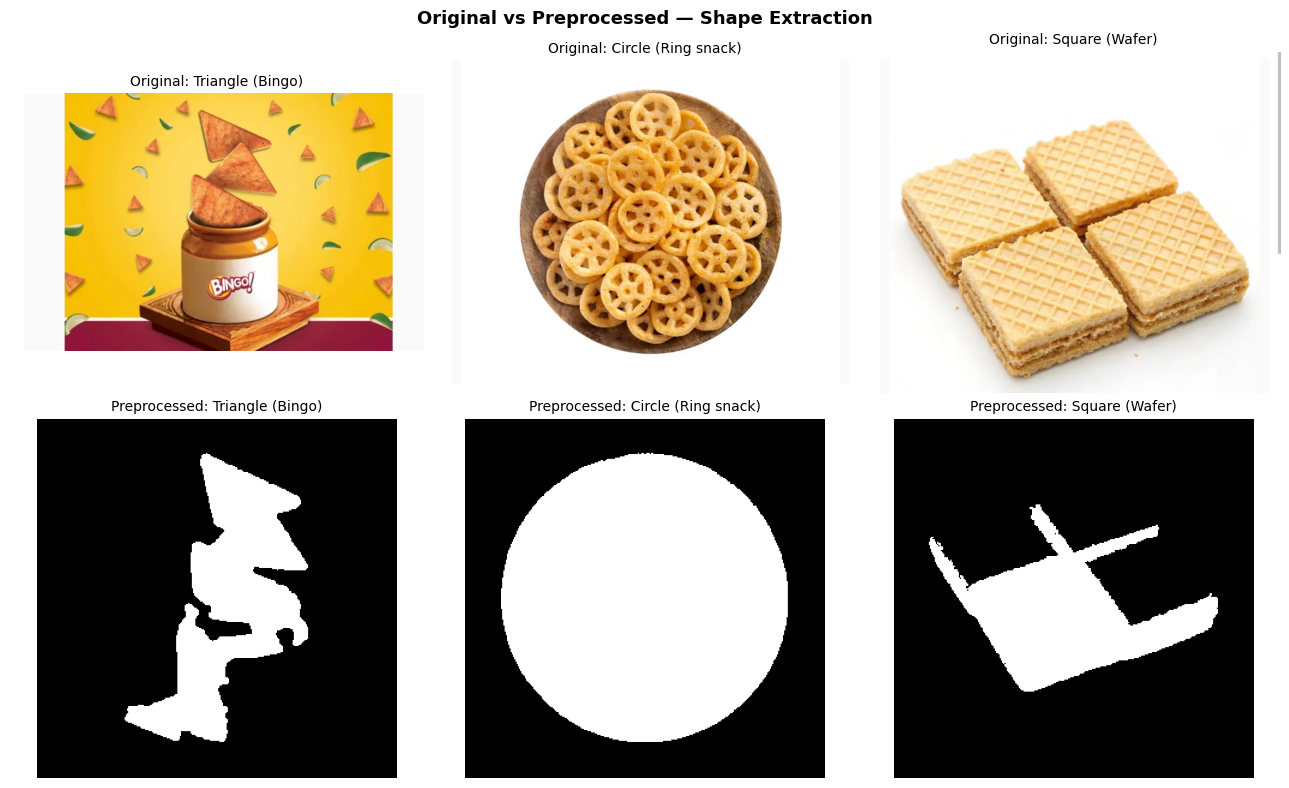

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

originals = [triangle_orig, circle_orig, square_orig]
processed = [triangle_clean, circle_clean, square_clean]
names     = ['Triangle (Bingo)', 'Circle (Ring snack)', 'Square (Wafer)']

for i in range(3):
    axes[0, i].imshow(cv2.cvtColor(originals[i], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'Original: {names[i]}', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(processed[i], cmap='gray')
    axes[1, i].set_title(f'Preprocessed: {names[i]}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Original vs Preprocessed — Shape Extraction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔗 Step 5 — Build Combined Input Image

We place all 3 preprocessed shapes side by side into one image.
This simulates a conveyor belt photo with 3 unknown items to classify.

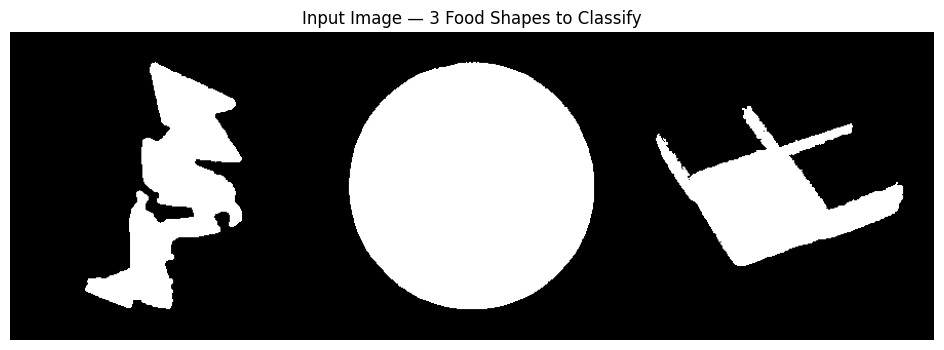

✅ Input image ready!


In [8]:
input_img = np.zeros((300, 900), dtype=np.uint8)
input_img[:, 0:300]   = triangle_clean
input_img[:, 300:600] = circle_clean
input_img[:, 600:900] = square_clean

plt.figure(figsize=(13, 4))
plt.imshow(input_img, cmap='gray')
plt.title('Input Image — 3 Food Shapes to Classify', fontsize=12)
plt.axis('off')
plt.show()
print('✅ Input image ready!')

## 🔍 Step 6 — Extract Template Contours

For each preprocessed template image, find its largest contour.
This contour is our **reference fingerprint** for that shape.

> 💬 We always take `max(..., key=cv2.contourArea)` to ensure we grab the
> actual shape, not any small noise contours.

In [9]:
def get_largest_contour(img):
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return max(contours, key=cv2.contourArea)

templates = {
    'Triangle (Bingo)'   : get_largest_contour(triangle_clean),
    'Circle (Ring snack)': get_largest_contour(circle_clean),
    'Square (Wafer)'     : get_largest_contour(square_clean),
}

for name, cnt in templates.items():
    print(f'{name:25s} → points: {len(cnt):4d}   area: {cv2.contourArea(cnt):.0f} px²')

Triangle (Bingo)          → points:  451   area: 14772 px²
Circle (Ring snack)       → points:  365   area: 44883 px²
Square (Wafer)            → points:  543   area: 14013 px²


## 🧠 Step 7 — Classify Each Shape using matchShapes

For every shape found in the input image, compare it against all 3 templates.

`cv2.matchShapes(A, B, method, 0)` internally:
1. Computes Hu Moments for both contours A and B
2. Log-transforms each moment
3. Returns sum of absolute differences → **lower = more similar**

We pick the template with the **lowest score** → that's the predicted label.

In [10]:
# Find contours in input
input_contours, _ = cv2.findContours(input_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
input_contours    = [c for c in input_contours if cv2.contourArea(c) > 500]

print(f'Found {len(input_contours)} shapes in input image\n')

results = []
for cnt in input_contours:
    scores = {}
    for name, tmpl_cnt in templates.items():
        score = cv2.matchShapes(cnt, tmpl_cnt, cv2.CONTOURS_MATCH_I1, 0)
        scores[name] = score

    best = min(scores, key=scores.get)
    results.append((cnt, best, scores))

    print(f'Predicted → {best}')
    for k, v in scores.items():
        marker = '✅' if k == best else '  '
        print(f'  {marker} {k:25s}: {v:.6f}')
    print()

Found 3 shapes in input image

Predicted → Square (Wafer)
     Triangle (Bingo)         : 0.900984
     Circle (Ring snack)      : 0.401639
  ✅ Square (Wafer)           : 0.000000

Predicted → Circle (Ring snack)
     Triangle (Bingo)         : 0.836922
  ✅ Circle (Ring snack)      : 0.000000
     Square (Wafer)           : 0.401639

Predicted → Triangle (Bingo)
  ✅ Triangle (Bingo)         : 0.000000
     Circle (Ring snack)      : 0.836922
     Square (Wafer)           : 0.900984



## 📐 Step 8 — Draw Results on Input Image

Annotate each detected shape with its predicted food label and a colored outline.

> 💬 `cv2.moments(cnt)` gives us the centroid coordinates so we know
> exactly where to place the text label on each shape.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


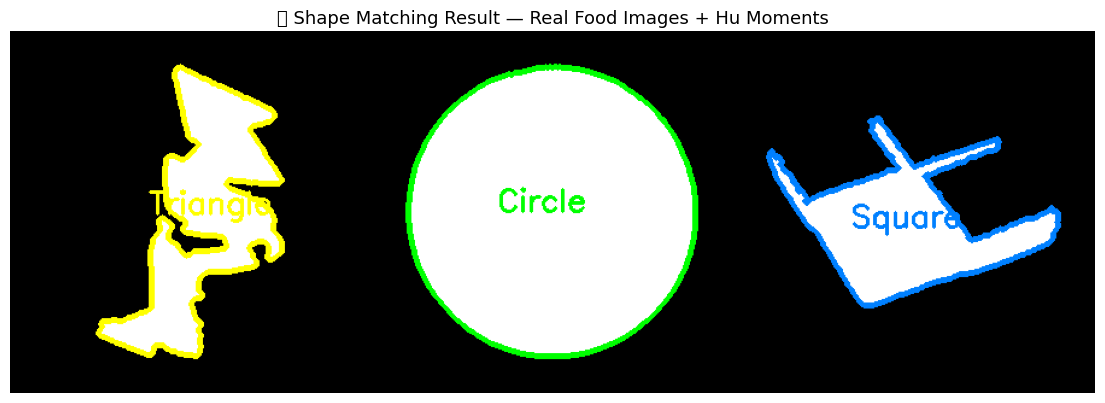

In [11]:
output = cv2.cvtColor(input_img, cv2.COLOR_GRAY2BGR)

colors = {
    'Triangle (Bingo)'   : (0, 255, 255),   # yellow
    'Circle (Ring snack)': (0, 255, 0),      # green
    'Square (Wafer)'     : (255, 128, 0),    # orange
}

for cnt, label, scores in results:
    color = colors[label]
    cv2.drawContours(output, [cnt], -1, color, 3)

    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        short = label.split('(')[0].strip()   # just shape name
        cv2.putText(output, short, (cx - 45, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.85, color, 2)

plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('✅ Shape Matching Result — Real Food Images + Hu Moments', fontsize=13)
plt.axis('off')
plt.show()

## 💾 Step 9 — Save & Download Result

In [12]:
from google.colab import files

cv2.imwrite('shape_match_result.png', output)
files.download('shape_match_result.png')
print('✅ Result saved and downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Result saved and downloaded!
